In [1]:
import geopandas as gpd

shp_file = "/Users/elqajjammohammed/Desktop/Extra-Work/PoCs/SatRing-One-Embedding-to-Bind-Them-all/data/raw/LNDCVR2023/Land Cover 2023.shp"

gdf = gpd.read_file(shp_file)
gdf.head(10)

/opt/anaconda3/envs/torch-env/lib/python3.11/site-packages/pyogrio/raw.py:198: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured 3D Polygon' is converted to 'Polygon Z'
  return ogr_read(


,class,province,district,shape_leng,area_ha,st_area_sh,st_length_,geometry
0,Cropland,Western,Nyamasheke,2.522712e+02,0.004380,4.379986e+01,2.522712e+02,"POLYGON Z ((395945.778 4720188.418 0, 395946.2..."
1,Forest,Western,Nyamasheke,2.522712e+02,0.004380,4.379986e+01,2.522712e+02,"POLYGON Z ((395945.778 4720188.418 0, 395946.2..."
2,Bareland,Southern,Huye,1.033394e+03,0.768043,7.680433e+03,1.033394e+03,"MULTIPOLYGON Z (((477712.183 4727742.451 0, 47..."
3,Built_Up_Area,Southern,Nyaruguru,5.375990e+06,7947.334411,7.947334e+07,5.375990e+06,"MULTIPOLYGON Z (((436319.308 4701099.489 0, 43..."
4,Waterbody,Southern,Nyaruguru,1.167685e+05,114.827903,1.148279e+06,1.167685e+05,"MULTIPOLYGON Z (((445642.786 4708433.334 0, 44..."
5,Wetland,Southern,Nyaruguru,3.789018e+04,0.165892,1.658916e+03,3.789018e+04,"MULTIPOLYGON Z (((450346.107 4703548.972 0, 45..."
6,Cropland,Southern,Huye,8.013410e+01,0.001811,1.810875e+01,8.013410e+01,"POLYGON Z ((457536.991 4717662.851 0, 457514.1..."
7,Forest,Southern,Huye,8.013410e+01,0.001811,1.810875e+01,8.013410e+01,"POLYGON Z ((457536.991 4717662.851 0, 457514.1..."
8,Cropland,Southern,Gisagara,3.834759e+02,0.784393,7.843935e+03,3.834759e+02,"POLYGON Z ((470872.665 4692474.059 0, 470868.6..."
9,Cropland,Southern,Nyamagabe,7.076449e+01,0.003176,3.176037e+01,7.076448e+01,"MULTIPOLYGON Z (((438834.558 4713801.692 0, 43..."


In [ ]:
import pandas as pd
import geopandas as gpd
from tqdm import tqdm
Rwanda_tiles = ['35MPT','35MQU','35MQS','35MQT','35MRS','35MRT','35MRU','36MTC','36MTD']
tiles_geo = '/Users/elqajjammohammed/Desktop/Extra-Work/PoCs/SatRing-One-Embedding-to-Bind-Them-all/sentinel2_tiling_grid.geojson'
lc = gpd.read_file('/Users/elqajjammohammed/Desktop/Extra-Work/PoCs/SatRing-One-Embedding-to-Bind-Them-all/data/raw/LNDCVR2023/Land Cover 2023.shp')


tiles = gpd.read_file(tiles_geo)

tiles = tiles[tiles['Name'].isin(Rwanda_tiles)]




if lc.crs != tiles.crs:
    lc = lc.to_crs(tiles.crs)

rows = []
for _, t in tqdm(tiles.iterrows()):
    tc = gpd.overlay(lc, gpd.GeoDataFrame(geometry=[t.geometry], crs=tiles.crs), how="intersection")
    if tc.empty:
        continue
    tc["area_ha"] = tc.geometry.area / 10000
    s = tc.groupby("class")["area_ha"].sum().reset_index()
    s["tile"] = t["Name"]
    rows.append(s)

df = pd.concat(rows, ignore_index=True)
df

# gdf.head(10)


/opt/anaconda3/envs/torch-env/lib/python3.11/site-packages/pyogrio/raw.py:198: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured 3D Polygon' is converted to 'Polygon Z'
  return ogr_read(
0it [00:00, ?it/s]

In [4]:
print("LC bounds:", lc.total_bounds)
print("Tiles bounds:", tiles.total_bounds)
print("Same CRS:", lc.crs == tiles.crs)


LC bounds: [28.86170769 -2.83996727 30.89907265 -1.04745027]
Tiles bounds: [27.89908282 -3.70569975 31.29058477 -0.90249122]
Same CRS: True


In [5]:
import geopandas as gpd
import rasterio
from rasterio.features import rasterize
from rasterio.transform import from_origin
import rasterio.mask
import numpy as np
import pandas as pd
from tqdm import tqdm

Rwanda_tiles = ['35MPT','35MQU','35MQS','35MQT','35MRS','35MRT','35MRU','36MTC','36MTD']
tiles = gpd.read_file('/Users/elqajjammohammed/Desktop/Extra-Work/PoCs/SatRing-One-Embedding-to-Bind-Them-all/sentinel2_tiling_grid.geojson')
tiles = tiles[tiles["Name"].isin(Rwanda_tiles)]

lc = gpd.read_file('/Users/elqajjammohammed/Desktop/Extra-Work/PoCs/SatRing-One-Embedding-to-Bind-Them-all/data/raw/LNDCVR2023/Land Cover 2023.shp')

if lc.crs != tiles.crs:
    lc = lc.to_crs(tiles.crs)

minx, miny, maxx, maxy = lc.total_bounds
res = 10
width = int((maxx - minx) / res)
height = int((maxy - miny) / res)
transform = from_origin(minx, maxy, res, res)

shapes = [(row.geometry, row["class"]) for _, row in lc.iterrows()]
lc_raster = rasterize(
    shapes,
    out_shape=(height, width),
    transform=transform,
    fill=0,
    dtype="int32"
)

raster_path = "lc10m.tif"
with rasterio.open(
    raster_path,
    "w",
    driver="GTiff",
    height=height,
    width=width,
    count=1,
    dtype="int32",
    crs=lc.crs,
    transform=transform
) as dst:
    dst.write(lc_raster, 1)

rows = []
with rasterio.open(raster_path) as src:
    pixel_area = abs(src.transform[0] * src.transform[4])
    for _, t in tqdm(tiles.iterrows()):
        inter = t.geometry.intersection(lc.unary_union)
        if inter.is_empty:
            continue
        out, _ = rasterio.mask.mask(src, [inter], crop=True)
        arr = out[0]
        mask = arr != 0
        if mask.sum() == 0:
            continue
        u, c = np.unique(arr[mask], return_counts=True)
        rows.append(pd.DataFrame({
            "tile": t["Name"],
            "class": u,
            "area_ha": c * pixel_area / 10000
        }))

df = pd.concat(rows, ignore_index=True)
df


/opt/anaconda3/envs/torch-env/lib/python3.11/site-packages/pyogrio/raw.py:198: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured 3D Polygon' is converted to 'Polygon Z'
  return ogr_read(


ValueError: width and height must be > 0

In [6]:
#faster
import geopandas as gpd
import pandas as pd
from tqdm import tqdm

Rwanda_tiles = ['35MPT','35MQU','35MQS','35MQT','35MRS','35MRT','35MRU','36MTC','36MTD']
tiles = gpd.read_file('/Users/elqajjammohammed/Desktop/Extra-Work/PoCs/SatRing-One-Embedding-to-Bind-Them-all/sentinel2_tiling_grid.geojson')
tiles = tiles[tiles["Name"].isin(Rwanda_tiles)]

lc = gpd.read_file('/Users/elqajjammohammed/Desktop/Extra-Work/PoCs/SatRing-One-Embedding-to-Bind-Them-all/data/raw/LNDCVR2023/Land Cover 2023.shp')

if lc.crs != tiles.crs:
    lc = lc.to_crs(tiles.crs)

lc_sindex = lc.sindex
rows = []

for _, t in tqdm(tiles.iterrows()):
    possible_idx = list(lc_sindex.intersection(t.geometry.bounds))
    if not possible_idx:
        continue
    subset = lc.iloc[possible_idx].copy()
    subset = subset[subset.intersects(t.geometry)]
    if subset.empty:
        continue
    subset["geom_inter"] = subset.geometry.intersection(t.geometry)
    subset["area_ha"] = subset["geom_inter"].area / 10000
    df_tile = subset.groupby("class")["area_ha"].sum().reset_index()
    df_tile["tile"] = t["Name"]
    rows.append(df_tile)

df = pd.concat(rows, ignore_index=True)
df


/opt/anaconda3/envs/torch-env/lib/python3.11/site-packages/pyogrio/raw.py:198: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured 3D Polygon' is converted to 'Polygon Z'
  return ogr_read(
0it [00:00, ?it/s]/var/folders/2b/hbh6xlkj0vbg0ddn5ktr66tm0000gn/T/ipykernel_75592/4246210590.py:27: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  subset["area_ha"] = subset["geom_inter"].area / 10000
1it [00:00,  1.89it/s]/var/folders/2b/hbh6xlkj0vbg0ddn5ktr66tm0000gn/T/ipykernel_75592/4246210590.py:27: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  subset["area_ha"] = subset["geom_inter"].area / 10000
2it [00:03,  1.95s/it]/var/folders/2b/hbh6xlkj0vbg0ddn5ktr66tm0000gn/T/ipykernel_75592/4246210590.

,class,area_ha,tile
0,Bareland,3.224701e-12,35MPT
1,Built_Up_Area,2.584212e-08,35MPT
2,Cropland,2.969146e-08,35MPT
3,Forest,2.199885e-08,35MPT
4,Grassland_and_Shrubland,2.470739e-09,35MPT
...,...,...,...
58,Cropland,1.169169e-05,36MTD
59,Forest,7.893222e-06,36MTD
60,Grassland_and_Shrubland,5.122349e-06,36MTD
61,Waterbody,1.457322e-06,36MTD


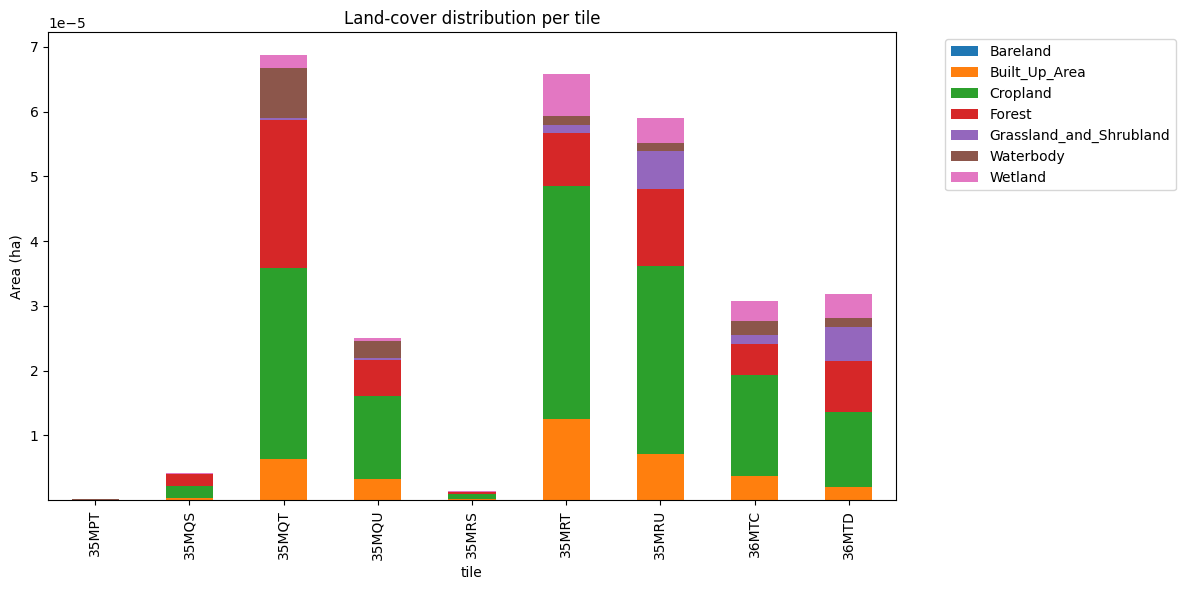

In [7]:
import matplotlib.pyplot as plt

df_pivot = df.pivot(index='tile', columns='class', values='area_ha').fillna(0)
df_pivot.plot(kind='bar', stacked=True, figsize=(12,6))
plt.ylabel("Area (ha)")
plt.title("Land-cover distribution per tile")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


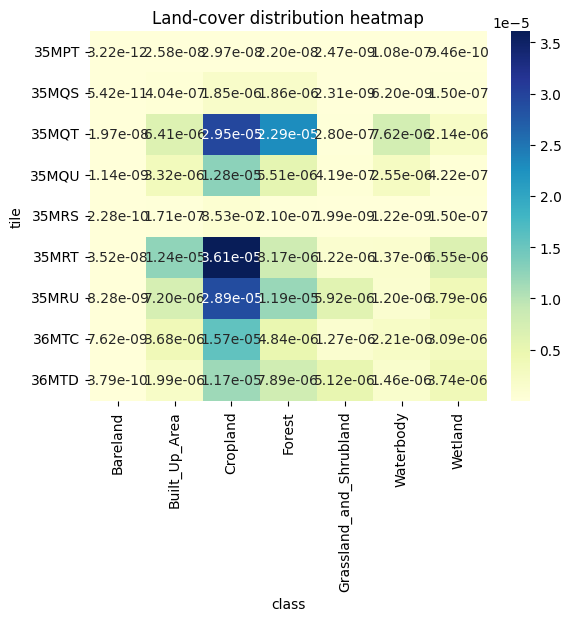

In [8]:
import seaborn as sns

df_heat = df.pivot(index='tile', columns='class', values='area_ha').fillna(0)
sns.heatmap(df_heat, annot=True, fmt=".2e", cmap="YlGnBu")
plt.title("Land-cover distribution heatmap")
plt.show()


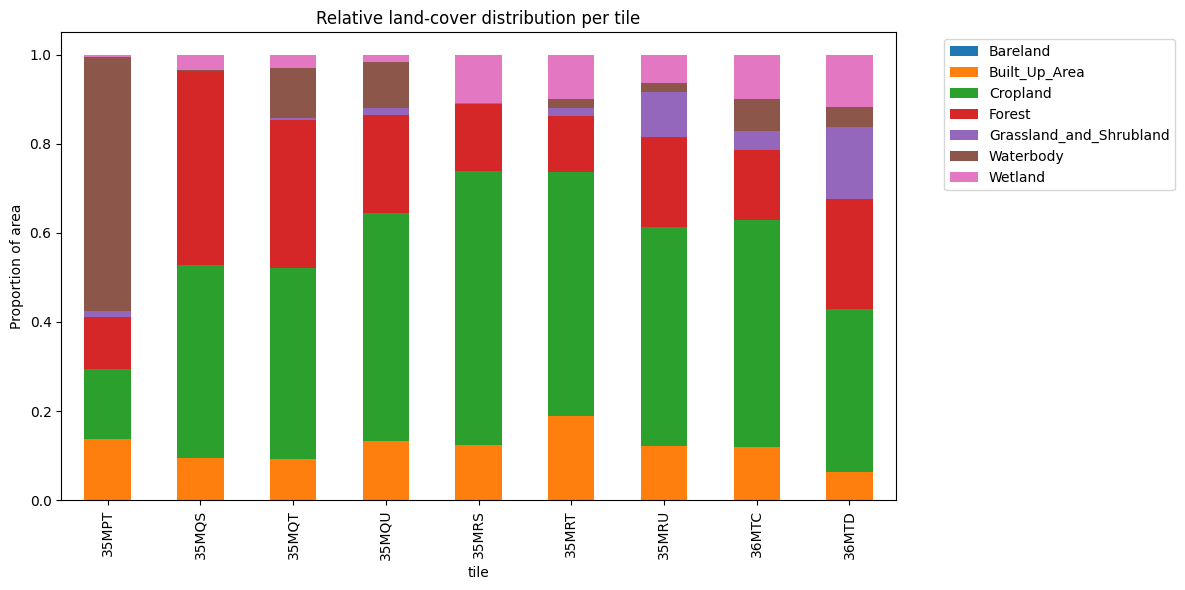

In [9]:
df_rel = df_pivot.div(df_pivot.sum(axis=1), axis=0)
df_rel.plot(kind='bar', stacked=True, figsize=(12,6))
plt.ylabel("Proportion of area")
plt.title("Relative land-cover distribution per tile")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [7]:
import geopandas as gpd
import numpy as np
import pandas as pd
from shapely.geometry import box
from scipy.stats import entropy
from tqdm import tqdm

Rwanda_tiles = ['35MPT','35MQU','35MQS','35MQT','35MRS','35MRT','35MRU','36MTC','36MTD']

tiles = gpd.read_file('/Users/elqajjammohammed/Desktop/Extra-Work/PoCs/SatRing-One-Embedding-to-Bind-Them-all/sentinel2_tiling_grid.geojson')
tiles = tiles[tiles["Name"].isin(Rwanda_tiles)]

lc = gpd.read_file('/Users/elqajjammohammed/Desktop/Extra-Work/PoCs/SatRing-One-Embedding-to-Bind-Them-all/data/raw/LNDCVR2023/Land Cover 2023.shp')

tiles = tiles.to_crs(epsg=32635)
lc = lc.to_crs(tiles.crs)

rwanda = gpd.GeoDataFrame(geometry=[lc.unary_union], crs=lc.crs)
lc_sindex = lc.sindex

patch_size_m = 2240
patch_list = []

for _, t in tiles.iterrows():
    minx, miny, maxx, maxy = t.geometry.bounds
    xs = np.arange(minx, maxx, patch_size_m)
    ys = np.arange(miny, maxy, patch_size_m)
    for x in xs:
        for y in ys:
            geom = box(x, y, x+patch_size_m, y+patch_size_m)
            if geom.intersects(rwanda.geometry.iloc[0]):
                patch_list.append({'tile': t['Name'], 'geometry': geom})

patches_gdf = gpd.GeoDataFrame(patch_list, crs=tiles.crs)

patch_labels = []

for _, p in tqdm(patches_gdf.iterrows(), total=len(patches_gdf)):
    idx = list(lc_sindex.intersection(p.geometry.bounds))
    if not idx:
        continue
    subset = lc.iloc[idx]
    subset = subset[subset.intersects(p.geometry)]
    if subset.empty:
        continue
    gi = subset.geometry.intersection(p.geometry)
    area = gi.area
    class_probs = area.groupby(subset['class']).sum()
    class_probs = class_probs / class_probs.sum()
    dom = class_probs.idxmax()
    ent = entropy(class_probs)
    patch_labels.append({'geometry': p.geometry, 'tile': p.tile, 'dominant_class': dom, 'entropy': ent})

patches = gpd.GeoDataFrame(patch_labels, crs=tiles.crs)
patches['weight'] = patches['entropy']
patches.loc[patches['dominant_class']=='Cropland', 'weight'] *= 1.2
patches['prob'] = patches['weight'] / patches['weight'].sum()

sample_size = min(1000, len(patches))
sampled_patches = patches.sample(n=sample_size, weights='prob', random_state=42)

sampled_patches


/opt/anaconda3/envs/torch-env/lib/python3.11/site-packages/pyogrio/raw.py:198: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured 3D Polygon' is converted to 'Polygon Z'
  return ogr_read(
/var/folders/2b/hbh6xlkj0vbg0ddn5ktr66tm0000gn/T/ipykernel_97047/2230690580.py:18: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  rwanda = gpd.GeoDataFrame(geometry=[lc.unary_union], crs=lc.crs)
100%|██████████| 7682/7682 [03:23<00:00, 37.76it/s] 


,geometry,tile,dominant_class,entropy,weight,prob
2997,"POLYGON ((811180 -206740, 811180 -204500, 8089...",35MRT,Cropland,1.330408,1.596490,0.000221
7142,"POLYGON ((885502.751 -201298.617, 885502.751 -...",36MTD,Cropland,1.007673,1.209208,0.000167
5396,"POLYGON ((871660 -131360, 871660 -129120, 8694...",35MRU,Cropland,0.672811,0.807373,0.000112
4550,"POLYGON ((806700 -209760, 806700 -207520, 8044...",35MRU,Cropland,1.030849,1.237019,0.000171
1483,"POLYGON ((789560 -278420, 789560 -276180, 7873...",35MQT,Cropland,1.324592,1.589511,0.000220
...,...,...,...,...,...,...
5716,"POLYGON ((889580 -160480, 889580 -158240, 8873...",35MRU,Cropland,0.896866,1.076240,0.000149
3319,"POLYGON ((826860 -242580, 826860 -240340, 8246...",35MRT,Cropland,0.843449,1.012139,0.000140
3340,"POLYGON ((829100 -276180, 829100 -273940, 8268...",35MRT,Cropland,1.156272,1.387527,0.000192
5453,"POLYGON ((876140 -187360, 876140 -185120, 8739...",35MRU,Cropland,0.966600,1.159920,0.000160


In [8]:
import geopandas as gpd
import folium
from folium.features import GeoJsonTooltip

rw = gpd.read_file("/Users/elqajjammohammed/Desktop/Extra-Work/PoCs/SatRing-One-Embedding-to-Bind-Them-all/rw.json")
sampled = sampled_patches.to_crs(rw.crs)

m = folium.Map(location=[-2.0, 30.0], zoom_start=7, tiles="cartodbpositron")

# Rwanda boundary only outlined
folium.GeoJson(
    rw,
    style_function=lambda x: {"fillOpacity": 0, "color": "black", "weight": 2},
).add_to(m)

colors = {
    "Cropland": "#a6cee3",
    "Forest": "#1f78b4",
    "Grassland_and_Shrubland": "#b2df8a",
    "Waterbody": "#33a02c",
    "Built_Up_Area": "#fb9a99",
    "Bareland": "#e31a1c",
    "Wetland": "#fdbf6f"
}

def style_func(feature):
    cls = feature['properties']['dominant_class']
    return {
        "fillColor": colors.get(cls, "#cccccc"),
        "color": "black",
        "weight": 0.5,
        "fillOpacity": 0.6
    }

folium.GeoJson(
    sampled,
    style_function=style_func,
    tooltip=GeoJsonTooltip(fields=["tile", "dominant_class", "entropy"])
).add_to(m)

m.save("sampledd_patches_map.html")


In [ ]:
import geopandas as gpd
import numpy as np
import pandas as pd
from shapely.geometry import box
from scipy.stats import entropy
from tqdm import tqdm

# ============================================================================
# CONFIG
# ============================================================================
Rwanda_tiles = ['35MPT','35MQU','35MQS','35MQT','35MRS','35MRT','35MRU','36MTC','36MTD']
patch_size_m = 2240
TARGET_SAMPLES = 15000  

# ============================================================================
# LOAD & GENERATE
# ============================================================================
tiles = gpd.read_file('/Users/elqajjammohammed/Desktop/Extra-Work/PoCs/SatRing-One-Embedding-to-Bind-Them-all/sentinel2_tiling_grid.geojson')
tiles = tiles[tiles["Name"].isin(Rwanda_tiles)]
lc = gpd.read_file('/Users/elqajjammohammed/Desktop/Extra-Work/PoCs/SatRing-One-Embedding-to-Bind-Them-all/data/raw/LNDCVR2023/Land Cover 2023.shp')

tiles = tiles.to_crs(epsg=32635)
lc = lc.to_crs(tiles.crs)
rwanda = gpd.GeoDataFrame(geometry=[lc.unary_union], crs=lc.crs)
lc_sindex = lc.sindex

# Generate all candidate patches
patch_list = []
for _, t in tiles.iterrows():
    minx, miny, maxx, maxy = t.geometry.bounds
    xs = np.arange(minx, maxx, patch_size_m)
    ys = np.arange(miny, maxy, patch_size_m)
    for x in xs:
        for y in ys:
            geom = box(x, y, x+patch_size_m, y+patch_size_m)
            if geom.intersects(rwanda.geometry.iloc[0]):
                centroid = geom.centroid
                patch_list.append({
                    'tile': t['Name'],
                    'geometry': geom,
                    'lon': centroid.x,
                    'lat': centroid.y
                })

patches_gdf = gpd.GeoDataFrame(patch_list, crs=tiles.crs)
print(f"Total candidates: {len(patches_gdf)}")

# ============================================================================
# COMPUTE CLASS & COMPLEXITY
# ============================================================================
patch_data = []
for _, p in tqdm(patches_gdf.iterrows(), total=len(patches_gdf)):
    idx = list(lc_sindex.intersection(p.geometry.bounds))
    if not idx:
        continue
    
    subset = lc.iloc[idx][lc.iloc[idx].intersects(p.geometry)]
    if subset.empty:
        continue
    
    # Compute class distribution
    gi = subset.geometry.intersection(p.geometry)
    area = gi.area
    class_probs = area.groupby(subset['class']).sum()
    class_probs = class_probs / class_probs.sum()
    
    dominant = class_probs.idxmax()
    ent = entropy(class_probs)
    
    patch_data.append({
        'geometry': p.geometry,
        'tile': p.tile,
        'lon': p.lon,
        'lat': p.lat,
        'dominant_class': dominant,
        'entropy': ent,
        'class_distribution': class_probs.to_dict()
    })

patches = gpd.GeoDataFrame(patch_data, crs=tiles.crs)
print(f"Valid patches: {len(patches)}")

# ============================================================================
# KEY PART: 2D STRATIFICATION (Class × Complexity)
# ============================================================================

# Define complexity bins based on entropy
patches['complexity'] = pd.cut(
    patches['entropy'],
    bins=[0, 0.5, 1.2, 5.0],
    labels=['homogeneous', 'moderate', 'complex']
)

print("\nDistribution by class and complexity:")
print(patches.groupby(['dominant_class', 'complexity']).size())

# ============================================================================
# BALANCED SAMPLING
# ============================================================================

# Get all (class, complexity) combinations
strata = patches.groupby(['dominant_class', 'complexity']).size()
n_strata = len(strata)

# Target samples per stratum
base_per_stratum = TARGET_SAMPLES // n_strata  # e.g., 15000 / 15 = 1000
min_per_stratum = 800  # Minimum to avoid underrepresentation

sampled_patches = []

for (cls, complexity), count in strata.items():
    stratum = patches[
        (patches['dominant_class'] == cls) & 
        (patches['complexity'] == complexity)
    ]
    
    # Sample from this stratum
    n_samples = min(
        max(min_per_stratum, base_per_stratum),  # At least min, target base
        len(stratum)  # Don't exceed available
    )
    
    sampled = stratum.sample(n=n_samples, random_state=42)
    sampled_patches.append(sampled)
    
    print(f"{cls:15s} × {complexity:12s}: sampled {n_samples:4d} / {len(stratum):5d}")

sampled_patches = gpd.GeoDataFrame(pd.concat(sampled_patches), crs=tiles.crs)
print(f"\nTotal sampled: {len(sampled_patches)}")

# ============================================================================
# SAVE
# ============================================================================
sampled_patches.to_file('patches_rwanda_stratified.geojson', driver='GeoJSON')

coords_df = pd.DataFrame({
    'patch_id': range(len(sampled_patches)),
    'tile': sampled_patches['tile'],
    'lon': sampled_patches['lon'],
    'lat': sampled_patches['lat'],
    'dominant_class': sampled_patches['dominant_class'],
    'complexity': sampled_patches['complexity'],
    'entropy': sampled_patches['entropy']
})
coords_df.to_csv('patches_rwanda_stratified.csv', index=False)

print("\n✓ Saved patches_rwanda_stratified.geojson")
print("✓ Saved patches_rwanda_stratified.csv")

/opt/anaconda3/envs/torch-env/lib/python3.11/site-packages/pyogrio/raw.py:198: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured 3D Polygon' is converted to 'Polygon Z'
  return ogr_read(
/var/folders/2b/hbh6xlkj0vbg0ddn5ktr66tm0000gn/T/ipykernel_97047/3898766292.py:24: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  rwanda = gpd.GeoDataFrame(geometry=[lc.unary_union], crs=lc.crs)


Total candidates: 7682


100%|██████████| 7682/7682 [03:26<00:00, 37.12it/s] 
/var/folders/2b/hbh6xlkj0vbg0ddn5ktr66tm0000gn/T/ipykernel_97047/3898766292.py:95: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(patches.groupby(['dominant_class', 'complexity']).size())
/var/folders/2b/hbh6xlkj0vbg0ddn5ktr66tm0000gn/T/ipykernel_97047/3898766292.py:102: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  strata = patches.groupby(['dominant_class', 'complexity']).size()


Valid patches: 7682

Distribution by class and complexity:
dominant_class           complexity 
Built_Up_Area            homogeneous      12
                         moderate        231
                         complex          76
Cropland                 homogeneous     345
                         moderate       4235
                         complex         556
Forest                   homogeneous     240
                         moderate        421
                         complex          52
Grassland_and_Shrubland  homogeneous      54
                         moderate        231
                         complex          30
Waterbody                homogeneous      79
                         moderate        131
                         complex          39
Wetland                  homogeneous     144
                         moderate        213
                         complex          51
dtype: int64
Built_Up_Area   × homogeneous : sampled   12 /    12
Built_Up_Area   × moderate  

In [13]:


import geopandas as gpd
import folium
from folium import plugins

# Load patches
patches = gpd.read_file('/Users/elqajjammohammed/Desktop/Extra-Work/PoCs/SatRing-One-Embedding-to-Bind-Them-all/notebooks/patches_rwanda_stratified.geojson')
patches = patches.to_crs(epsg=4326)  # Convert to lat/lon

# Create map
m = folium.Map(location=[-1.95, 29.87], zoom_start=9, tiles='OpenStreetMap')

# Colors
complexity_colors = {
    'homogeneous': '#3498db',
    'moderate': '#f39c12', 
    'complex': '#e74c3c'
}

# Add patches
for idx, row in patches.iterrows():
    color = complexity_colors.get(row['complexity'], '#95a5a6')
    
    folium.Rectangle(
        bounds=[[row.geometry.bounds[1], row.geometry.bounds[0]],
                [row.geometry.bounds[3], row.geometry.bounds[2]]],
        color=color,
        fill=True,
        fillColor=color,
        fillOpacity=0.5,
        weight=1,
        popup=f"""<b>Patch {idx}</b><br>
                  Class: {row['dominant_class']}<br>
                  Complexity: {row['complexity']}<br>
                  Entropy: {row['entropy']:.2f}"""
    ).add_to(m)

m.save('patches_map.html')